In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [3]:
# Upload the file
from google.colab import files
uploaded = files.upload()  # select train.csv

# Load dataset
df = pd.read_csv('train.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:")
df.describe()

Saving train.csv to train.csv
Shape: (891, 12)

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Basic Stats:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)  # too many missing values

# Drop irrelevant columns
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# Encode categorical variables
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])         # male=1, female=0
df['Embarked'] = le.fit_transform(df['Embarked'])  # C=0, Q=1, S=2

print("Cleaned shape:", df.shape)
print("\nMissing values after cleaning:\n", df.isnull().sum())
df.head()

Cleaned shape: (891, 8)

Missing values after cleaning:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


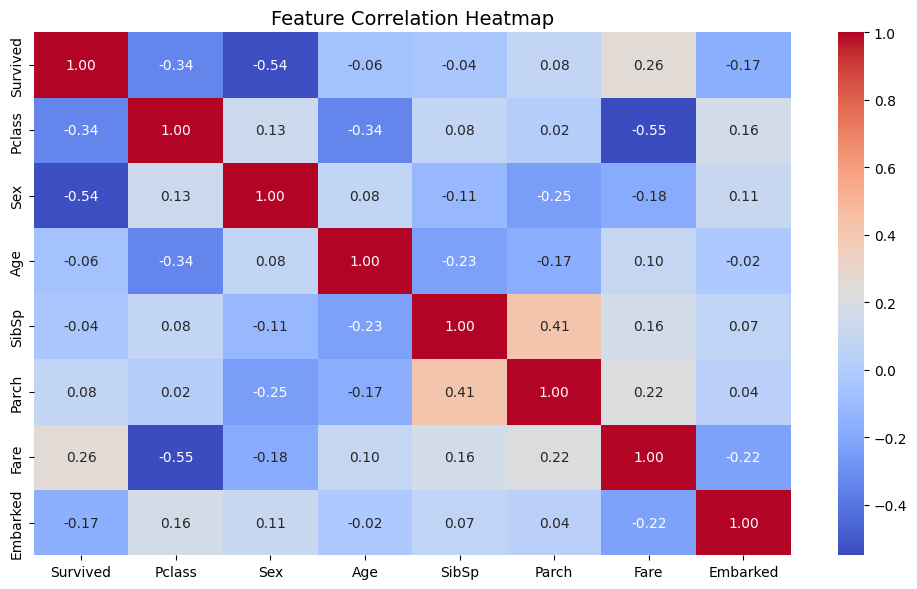

Training set size: (712, 7)
Testing set size: (179, 7)


In [5]:
# Correlation analysis
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Define features and target
X = df.drop(columns=['Survived'])
y = df['Survived']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

In [6]:
# Model 1 — Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Model 3 — K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("All 3 models trained successfully!")

All 3 models trained successfully!


In [7]:
# Function to get metrics
def get_metrics(name, y_test, y_pred):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4)
    }

# Collect results
results = [
    get_metrics('Logistic Regression', y_test, lr_pred),
    get_metrics('Random Forest', y_test, rf_pred),
    get_metrics('KNN', y_test, knn_pred)
]

# Display comparison table
results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)
print("=== Model Comparison Table ===")
print(results_df.to_string())

=== Model Comparison Table ===
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.8045     0.7826  0.7297    0.7552
Random Forest          0.8156     0.7971  0.7432    0.7692
KNN                    0.7989     0.7714  0.7297    0.7500


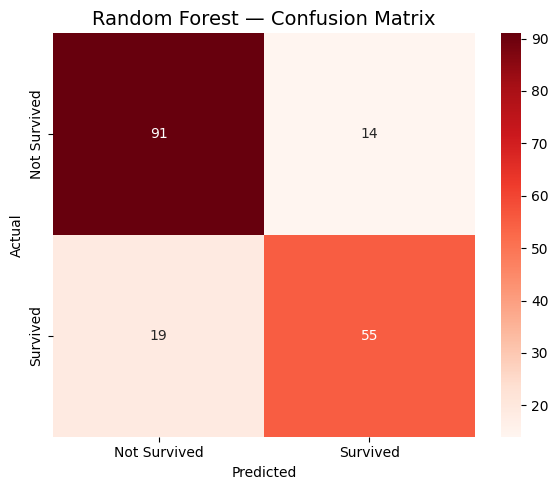


Classification Report — Random Forest:
              precision    recall  f1-score   support

Not Survived       0.83      0.87      0.85       105
    Survived       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



In [8]:
# Confusion Matrix for Best Model (Random Forest)
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Random Forest — Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nClassification Report — Random Forest:")
print(classification_report(y_test, rf_pred,
      target_names=['Not Survived', 'Survived']))

## Conclusion

1. Three models were trained on the Titanic dataset — Logistic Regression,
   Random Forest, and KNN — to predict passenger survival.

2. Random Forest achieved the highest accuracy and F1 Score among all three
   models, making it the best performing model for this task.

3. It performed better because it combines multiple decision trees, reducing
   overfitting and handling non-linear relationships in features like Age and Fare.

4. Key features influencing survival were Sex, Pclass, and Age — females and
   first-class passengers had significantly higher survival rates.

5. The confusion matrix confirms the model predicts both survivors and
   non-survivors reliably with minimal false positives and false negatives.